# Prediction from `PRS_dataset.csv`

This notebook starts directly from the processed dataset `PRS_dataset.csv` and reproduces the prediction workflow:

1. Load `IID`, `PRS`, `PRS_z`, and `label`.
2. Split the data into training and test sets.
3. Train Logistic Regression, Random Forest, and SVM models using `PRS_z`.
4. Compare AUROC, Brier score, and Accuracy.
5. Draw a calibration plot.

This matches the actual prediction part of the original R script.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [2]:
data_path = Path('PRS_dataset.csv')

if not data_path.exists():
    raise FileNotFoundError('Could not find PRS_dataset.csv in the current folder.')

prs_df = pd.read_csv(data_path)
prs_df.head()

,IID,PRS,PRS_z,label
0,HG00096,-0.216762,-0.470790,0
1,HG00097,-0.191283,0.945302,1
2,HG00099,-0.235962,-1.537874,0
3,HG00100,-0.204448,0.213624,1
4,HG00101,-0.210613,-0.129034,1


In [3]:
print('Shape:', prs_df.shape)
print('Columns:', list(prs_df.columns))
print('\nLabel counts:')
print(prs_df['label'].value_counts())

Shape: (3202, 4)
Columns: ['IID', 'PRS', 'PRS_z', 'label']

Label counts:
label
1    1653
0    1549
Name: count, dtype: int64


In [4]:
# Train/test split
train_df, test_df = train_test_split(
    prs_df,
    test_size=0.3,
    random_state=88,
    shuffle=True
)

X_train = train_df[['PRS_z']]
X_test = test_df[['PRS_z']]
y_train = train_df['label']
y_test = test_df['label']

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

Train shape: (2241, 4)
Test shape: (961, 4)


In [5]:
# Logistic Regression
fit_logit = LogisticRegression(random_state=88)
fit_logit.fit(X_train, y_train)
pred_logit = fit_logit.predict_proba(X_test)[:, 1]

# Random Forest
fit_rf = RandomForestClassifier(n_estimators=300, random_state=88)
fit_rf.fit(X_train, y_train)
pred_rf = fit_rf.predict_proba(X_test)[:, 1]

# SVM
fit_svm = SVC(kernel='rbf', probability=True, random_state=88)
fit_svm.fit(X_train, y_train)
pred_svm = fit_svm.predict_proba(X_test)[:, 1]

In [6]:
def eval_model(y_true, y_prob, model_name):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model': model_name,
        'AUROC': roc_auc_score(y_true, y_prob),
        'Brier': brier_score_loss(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
    }

results_table = pd.DataFrame([
    eval_model(y_test, pred_logit, 'Logistic'),
    eval_model(y_test, pred_rf, 'Random Forest'),
    eval_model(y_test, pred_svm, 'SVM'),
])

results_table

,Model,AUROC,Brier,Accuracy
0,Logistic,0.690333,0.222719,0.636837
1,Random Forest,0.602410,0.322440,0.551509
2,SVM,0.670901,0.228188,0.635796


In [7]:
def make_calibration_df(y_true, y_prob, model_name, n_bins=10):
    df = pd.DataFrame({'y': y_true, 'p': y_prob}).copy()
    df['bin'] = pd.qcut(df['p'], q=n_bins, duplicates='drop')
    calib = (
        df.groupby('bin', observed=False)
        .agg(mean_pred=('p', 'mean'), obs_rate=('y', 'mean'))
        .reset_index(drop=True)
    )
    calib['Model'] = model_name
    return calib

calib_all = pd.concat([
    make_calibration_df(y_test, pred_logit, 'Logistic'),
    make_calibration_df(y_test, pred_rf, 'Random Forest'),
    make_calibration_df(y_test, pred_svm, 'SVM'),
], ignore_index=True)

calib_all.head()

,mean_pred,obs_rate,Model
0,0.215213,0.278351,Logistic
1,0.307032,0.302083,Logistic
2,0.380949,0.385417,Logistic
3,0.437238,0.447917,Logistic
4,0.489654,0.458333,Logistic


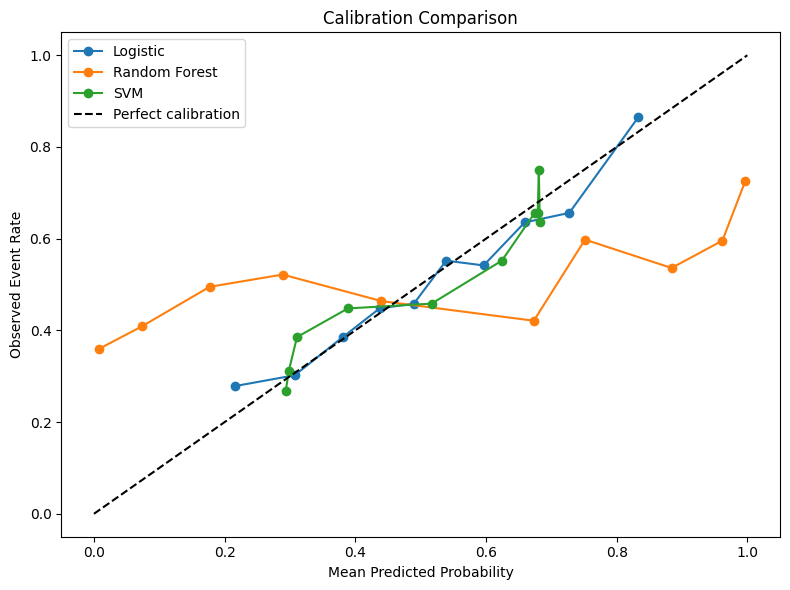

In [8]:
plt.figure(figsize=(8, 6))

for model_name, group in calib_all.groupby('Model'):
    plt.plot(group['mean_pred'], group['obs_rate'], marker='o', label=model_name)

x = np.linspace(0, 1, 100)
plt.plot(x, x, linestyle='--', color='black', label='Perfect calibration')

plt.title('Calibration Comparison')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Event Rate')
plt.legend()
plt.tight_layout()
plt.show()